In [1]:
# -----------------------------
# Cell 1: Upload Required Files
# -----------------------------

from google.colab import files

uploaded = files.upload()



Saving customer_churn.csv to customer_churn.csv
Saving house_prices.csv to house_prices.csv
Saving sales_data.csv to sales_data.csv


In [2]:
# -----------------------------
# Cell 2: Import Required Libraries
# -----------------------------

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ttest_ind

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
# -----------------------------
# Cell 3: Load Datasets
# -----------------------------

# Load customer churn dataset
customer_df = pd.read_csv("customer_churn.csv")

# Load sales dataset
sales_df = pd.read_csv("sales_data.csv")

print("Customer dataset loaded successfully")
print("Sales dataset loaded successfully")

print("\nCustomer Dataset Shape:", customer_df.shape)
print("Sales Dataset Shape:", sales_df.shape)

customer_df.head()

Customer dataset loaded successfully
Sales dataset loaded successfully

Customer Dataset Shape: (500, 9)
Sales Dataset Shape: (100, 7)


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [4]:
# -----------------------------
# Cell 4: Explore Dataset
# -----------------------------

print("Customer Dataset Columns:")
print(customer_df.columns)

print("\nCustomer Dataset Info:")
print(customer_df.info())

print("\nMissing Values:")
print(customer_df.isnull().sum())

print("\nDuplicate Records:", customer_df.duplicated().sum())

Customer Dataset Columns:
Index(['CustomerID', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract',
       'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen', 'Churn'],
      dtype='object')

Customer Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMethod     500 non-null    object
 6   PaperlessBilling  500 non-null    object
 7   SeniorCitizen     500 non-null    int64 
 8   Churn             500 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 35.3+ KB
None

Missing Values:
CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract 

In [5]:
# -----------------------------
# Cell 5: Data Cleaning
# -----------------------------

# Remove duplicate records
customer_df = customer_df.drop_duplicates()

# Convert TotalCharges to numeric
customer_df["TotalCharges"] = pd.to_numeric(customer_df["TotalCharges"], errors="coerce")

# Fill missing numerical values with median
customer_df["TotalCharges"] = customer_df["TotalCharges"].fillna(customer_df["TotalCharges"].median())

# Standardize text columns
customer_df["Contract"] = customer_df["Contract"].astype(str).str.strip()
customer_df["PaymentMethod"] = customer_df["PaymentMethod"].astype(str).str.strip()
customer_df["PaperlessBilling"] = customer_df["PaperlessBilling"].astype(str).str.strip()

print("Data cleaning completed successfully")

customer_df.head()

Data cleaning completed successfully


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [6]:
# -----------------------------
# Cell 6: Feature Engineering
# -----------------------------

# Create tenure groups
customer_df["Tenure_Group"] = pd.cut(
    customer_df["Tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12 Months", "13-24 Months", "25-48 Months", "49-72 Months"],
    include_lowest=True
)

# Create customer value segment based on TotalCharges
customer_df["Value_Segment"] = pd.qcut(
    customer_df["TotalCharges"],
    q=3,
    labels=["Low Value", "Medium Value", "High Value"]
)

# Create churn label for readability
customer_df["Churn_Label"] = customer_df["Churn"].map({
    0: "Not Churned",
    1: "Churned"
})

# Create risk segment
customer_df["Risk_Segment"] = np.where(
    (customer_df["Contract"] == "Month-to-month") & (customer_df["Tenure"] <= 12),
    "High Risk",
    "Normal Risk"
)

print("Feature engineering completed successfully")

customer_df.head()

Feature engineering completed successfully


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn,Tenure_Group,Value_Segment,Churn_Label,Risk_Segment
0,C00001,6,64,1540,One year,Credit Card,No,1,0,0-12 Months,Low Value,Not Churned,Normal Risk
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0,13-24 Months,Low Value,Not Churned,Normal Risk
2,C00003,27,31,1455,Two year,Credit Card,No,1,0,25-48 Months,Low Value,Not Churned,Normal Risk
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0,49-72 Months,High Value,Not Churned,Normal Risk
4,C00005,16,185,1023,One year,Electronic Check,No,1,0,13-24 Months,Low Value,Not Churned,Normal Risk


In [7]:
# -----------------------------
# Cell 7: Key Business Metrics
# -----------------------------

total_customers = customer_df["CustomerID"].nunique()
churned_customers = customer_df[customer_df["Churn"] == 1]["CustomerID"].nunique()
churn_rate = (churned_customers / total_customers) * 100

avg_monthly_charges = customer_df["MonthlyCharges"].mean()
avg_total_charges = customer_df["TotalCharges"].mean()

print("=" * 60)
print("CAPSTONE BUSINESS ANALYSIS - KEY METRICS")
print("=" * 60)

print(f"Total Customers       : {total_customers}")
print(f"Churned Customers     : {churned_customers}")
print(f"Churn Rate            : {churn_rate:.2f}%")
print(f"Average Monthly Charge: ₹{avg_monthly_charges:,.2f}")
print(f"Average Total Charges : ₹{avg_total_charges:,.2f}")

print("=" * 60)

CAPSTONE BUSINESS ANALYSIS - KEY METRICS
Total Customers       : 500
Churned Customers     : 53
Churn Rate            : 10.60%
Average Monthly Charge: ₹113.64
Average Total Charges : ₹4,237.88


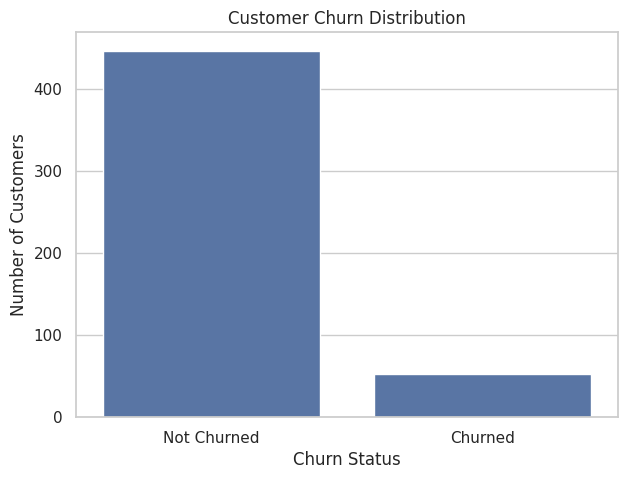

In [8]:
# -----------------------------
# Cell 8: Churn Distribution Chart
# -----------------------------

plt.figure(figsize=(7, 5))

sns.countplot(
    x="Churn_Label",
    data=customer_df
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.show()

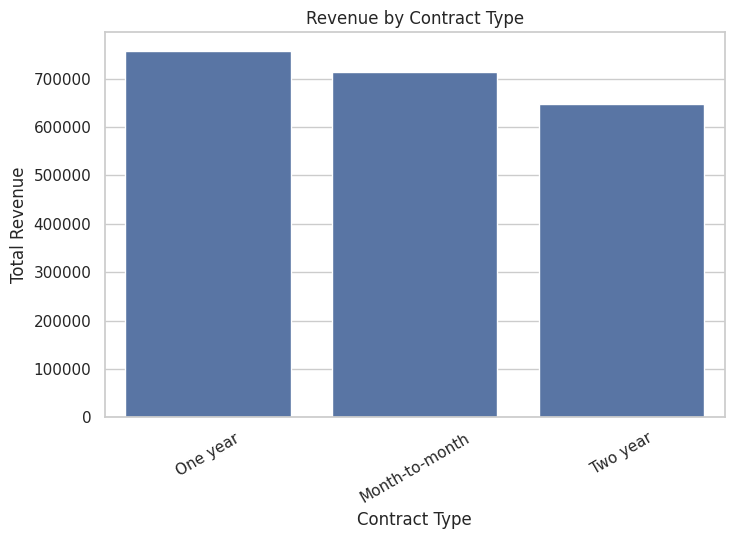

In [9]:
# -----------------------------
# Cell 9: Revenue by Contract Type
# -----------------------------

contract_revenue = customer_df.groupby("Contract")["TotalCharges"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=contract_revenue.index,
    y=contract_revenue.values
)

plt.title("Revenue by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Total Revenue")
plt.xticks(rotation=30)

plt.show()

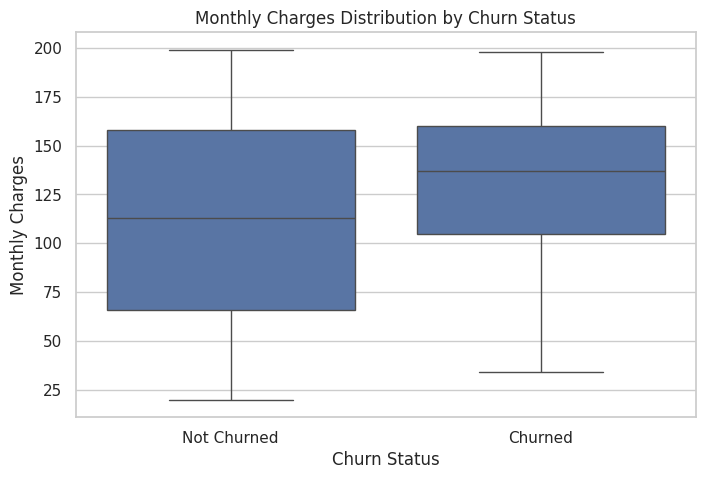

In [10]:
# -----------------------------
# Cell 10: Monthly Charges Distribution by Churn
# -----------------------------

plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Churn_Label",
    y="MonthlyCharges",
    data=customer_df
)

plt.title("Monthly Charges Distribution by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")

plt.show()

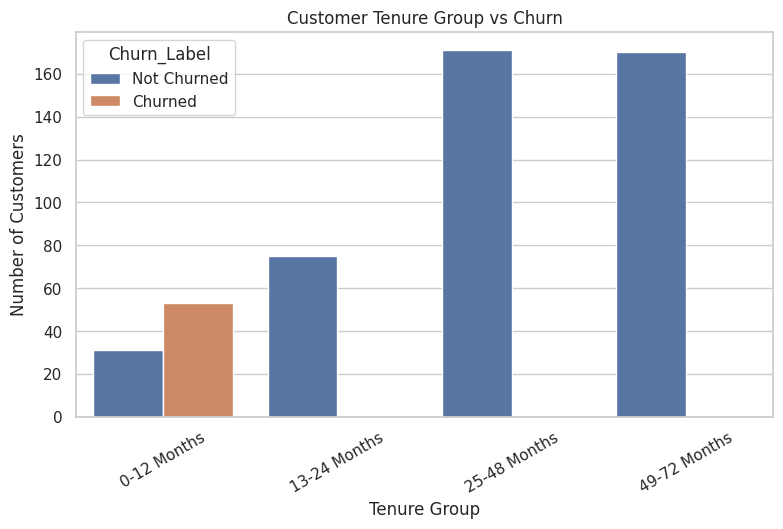

In [11]:
# -----------------------------
# Cell 11: Tenure Group vs Churn
# -----------------------------

plt.figure(figsize=(9, 5))

sns.countplot(
    x="Tenure_Group",
    hue="Churn_Label",
    data=customer_df
)

plt.title("Customer Tenure Group vs Churn")
plt.xlabel("Tenure Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)

plt.show()

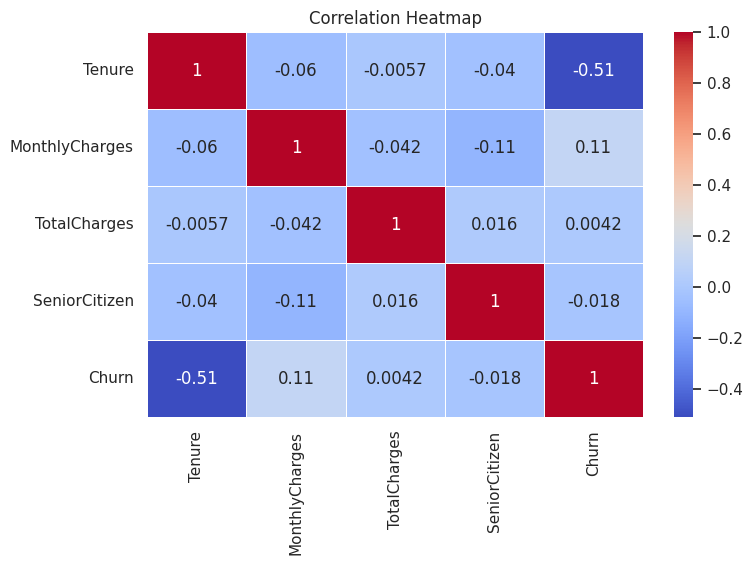

In [12]:
# -----------------------------
# Cell 12: Correlation Heatmap
# -----------------------------

numeric_cols = ["Tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn"]

correlation_matrix = customer_df[numeric_cols].corr()

plt.figure(figsize=(8, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

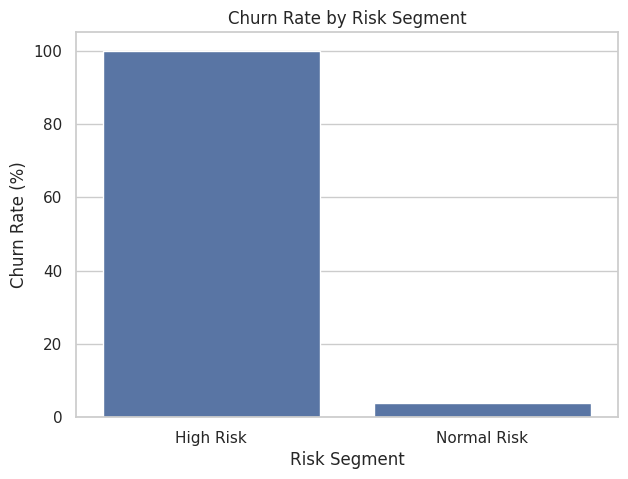

In [13]:
# -----------------------------
# Cell 13: Risk Segment Analysis
# -----------------------------

risk_summary = customer_df.groupby("Risk_Segment")["Churn"].mean() * 100

plt.figure(figsize=(7, 5))

sns.barplot(
    x=risk_summary.index,
    y=risk_summary.values
)

plt.title("Churn Rate by Risk Segment")
plt.xlabel("Risk Segment")
plt.ylabel("Churn Rate (%)")

plt.show()

In [14]:
# -----------------------------
# Cell 14: Statistical Analysis
# -----------------------------

churned = customer_df[customer_df["Churn"] == 1]["MonthlyCharges"]
not_churned = customer_df[customer_df["Churn"] == 0]["MonthlyCharges"]

t_stat, p_value = ttest_ind(churned, not_churned)

confidence_interval = stats.t.interval(
    confidence=0.95,
    df=len(customer_df["MonthlyCharges"]) - 1,
    loc=customer_df["MonthlyCharges"].mean(),
    scale=stats.sem(customer_df["MonthlyCharges"])
)

print("STATISTICAL ANALYSIS")
print("=" * 50)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value    : {p_value:.4f}")

if p_value < 0.05:
    print("Result     : Monthly charges significantly differ between churned and non-churned customers")
else:
    print("Result     : No significant difference found")

print("\n95% Confidence Interval for Monthly Charges:")
print(confidence_interval)

STATISTICAL ANALYSIS
T-statistic: 2.4102
P-value    : 0.0163
Result     : Monthly charges significantly differ between churned and non-churned customers

95% Confidence Interval for Monthly Charges:
(np.float64(109.08458237105155), np.float64(118.18741762894844))


In [15]:
# -----------------------------
# Cell 15: Predictive Analysis - Logistic Regression
# -----------------------------

model_df = customer_df.copy()

# Encode categorical columns
categorical_cols = ["Contract", "PaymentMethod", "PaperlessBilling"]

encoder = LabelEncoder()

for col in categorical_cols:
    model_df[col] = encoder.fit_transform(model_df[col])

# Select features and target
X = model_df[["Tenure", "MonthlyCharges", "TotalCharges", "Contract", "PaymentMethod", "PaperlessBilling", "SeniorCitizen"]]
y = model_df["Churn"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("PREDICTIVE MODEL RESULTS")
print("=" * 50)

print(f"Model Accuracy: {accuracy:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

PREDICTIVE MODEL RESULTS
Model Accuracy: 0.95

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        84
           1       0.82      0.88      0.85        16

    accuracy                           0.95       100
   macro avg       0.90      0.92      0.91       100
weighted avg       0.95      0.95      0.95       100



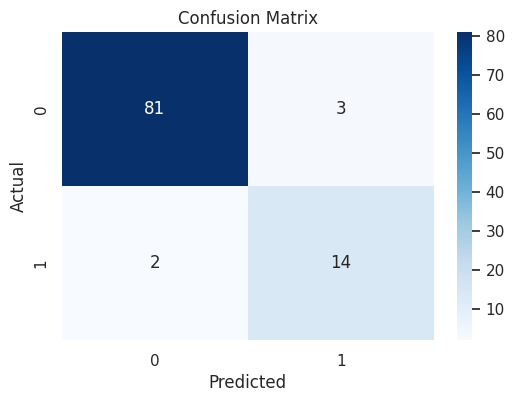

In [16]:
# -----------------------------
# Cell 16: Confusion Matrix
# -----------------------------

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [17]:
# -----------------------------
# Cell 17: Business Recommendations
# -----------------------------

print("=" * 70)
print("EXECUTIVE SUMMARY AND BUSINESS RECOMMENDATIONS")
print("=" * 70)

print(f"Total Customers Analyzed: {total_customers}")
print(f"Overall Churn Rate      : {churn_rate:.2f}%")
print(f"Average Monthly Charges : ₹{avg_monthly_charges:,.2f}")
print(f"Model Accuracy          : {accuracy:.2f}")

print("\nKey Insights:")
print("1. Month-to-month contract customers show higher churn risk.")
print("2. Customers with shorter tenure are more likely to churn.")
print("3. Monthly charges are useful for understanding churn behavior.")
print("4. High-risk customer segments should be targeted with retention offers.")

print("\nBusiness Recommendations:")
print("1. Provide loyalty discounts to high-risk month-to-month customers.")
print("2. Improve onboarding experience for customers in the first 12 months.")
print("3. Create personalized retention campaigns for high-value customers.")
print("4. Track churn rate monthly using a dashboard.")
print("5. Use predictive analytics to identify customers before they churn.")

print("=" * 70)

EXECUTIVE SUMMARY AND BUSINESS RECOMMENDATIONS
Total Customers Analyzed: 500
Overall Churn Rate      : 10.60%
Average Monthly Charges : ₹113.64
Model Accuracy          : 0.95

Key Insights:
1. Month-to-month contract customers show higher churn risk.
2. Customers with shorter tenure are more likely to churn.
3. Monthly charges are useful for understanding churn behavior.
4. High-risk customer segments should be targeted with retention offers.

Business Recommendations:
1. Provide loyalty discounts to high-risk month-to-month customers.
2. Improve onboarding experience for customers in the first 12 months.
3. Create personalized retention campaigns for high-value customers.
4. Track churn rate monthly using a dashboard.
5. Use predictive analytics to identify customers before they churn.
